# Model Spikey observed by *Kepler* + *Plato* with JAXNS

In this notebook we use the Bayesian inference package `JAXNS`, using nested sampling, to model the Plato simulation of Spikey.

In [1]:
%load_ext autoreload
%autoreload 2
# %matplotlib widget

In [2]:
# Built-in
import os
import sys
import json
import copy
import warnings

# Dependencies
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from jax import numpy as jnp
import numpyro
import numpyro.distributions as dist

# Select number of CPUs
numpyro.enable_x64()
numpyro.set_host_device_count(6)

# Internal methods
sys.path.append('../src')
from smbhb_jax import smbhb_jax
import smbhb as smbhb
import bayes as bs
import utils as ut
import plots as pt
pt.setup()

INFO:2026-04-13 15:14:23,403:jax._src.xla_bridge:810: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


In [3]:
# Hide warnings
warnings.filterwarnings("ignore")

In [4]:
# Global paths
path = Path('../')
ddir = path / 'data'
rdir = path / 'results'
fdir = path / 'figures'
cv = 'tomato'
cm = 'orange'
c0 = 'lightseagreen'
c1 = 'mediumorchid'

---
## 1. *Kepler* + *Plato* 2-yr light curve
---

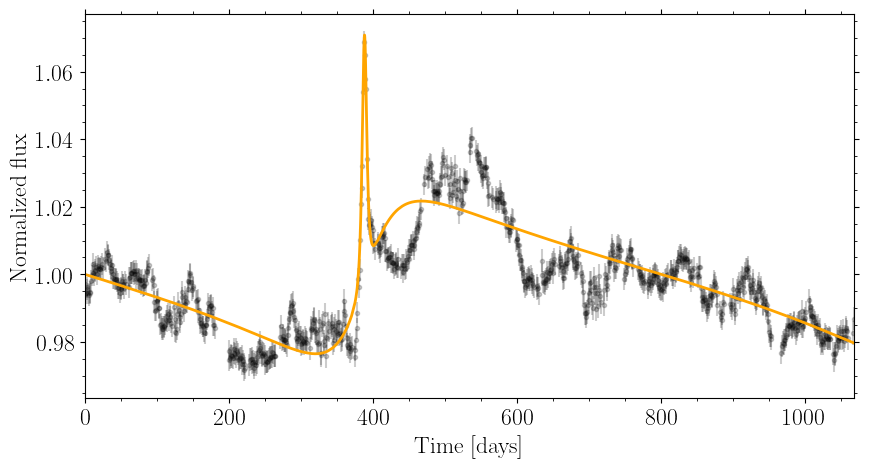

In [5]:
# Load Hu+2020 binned light curve of Spikey 
df_kepler = pd.read_feather(ddir / 'lc_spikey_kepler_smith2016.ftr')
Q0_kepler = 12

# Generate relativistic Spikey model
params = smbhb.model_params()
params.sigma = 0
params.t0 = 1.0544
model = smbhb.model(params)
dm_kepler = model.light_curve(df_kepler.time.to_numpy(), df=True)

# Create a 1-d binned light curve and plot
df_kepler = ut.bin_lc(df_kepler, bin_size=1)

# Plot light curve
fig, ax = pt.plot_lc(df_kepler, dm_kepler, cm=cm, alpha=0.2);

In [6]:
# # Load variable template
# sdir = path / '../workdir/smbhb/simulations/lcs/'
# dv_plato = pd.read_csv(sdir / 'varsource' / 'varsource_spikey_fiducial.txt', 
#                  sep=' ', names=['time', 'dmag'])
# dv_plato.time /= 86400
# dv_plato['flux'] = ut.mag2flux(dv_plato.dmag)
# # Bin to 1-hour light curve 
# dx = pd.DataFrame({'time':dv_plato.time.to_numpy(), 'flux':dv_plato.flux.to_numpy()})
# dx = ut.bin_lc(dx, bin_size=600/86400)
# dx.reset_index(drop=True).to_feather(ddir / 'lc_spikey_plato_template.ftr')

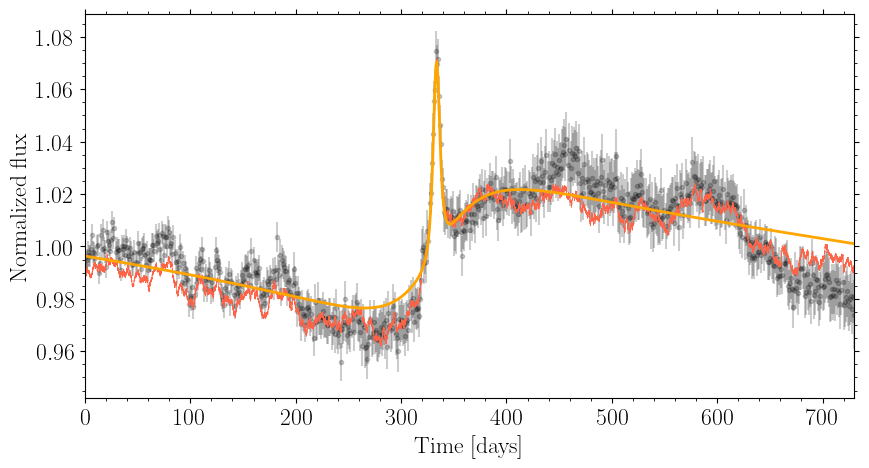

In [7]:
# Load Plato simulation and template of Spikey 
df_plato = pd.read_feather(ddir / 'lc_spikey_plato_fiducial.ftr')
dv_plato = pd.read_feather(ddir / 'lc_spikey_plato_template.ftr')
Q0_plato = 9

# Bin to 1-hour light curve 
df_plato = ut.bin_lc(df_plato, bin_size=1)

# Cut light curve to 2-year duration
df_plato = df_plato[df_plato.time < 4*ut.year2day()]

# Generate relativistic Spikey model
params = smbhb.model_params()
params.t0    = 0.712
params.sigma = 0 
model = smbhb.model(params)
dm_plato = model.light_curve(df_plato.time.to_numpy(), df=True)

# Set first exposure to zero
t0_offset = df_plato.time.iloc[0]
df_plato.time -= t0_offset
dv_plato.time -= t0_offset
dm_plato.time -= t0_offset

# Secure mean level
mean = np.mean(df_plato.flux) - 1
df_plato.flux -= mean

# Plot light curve
fig, ax = pt.plot_lc(df_plato, dv_plato, cm=cv, lw=0.5)
ax.plot(dm_plato.time, dm_plato.flux, '-', c=cm, lw=2);

# Add offset to Plato light curve 
# Test with t0 = 0.712
t0_kepler = 1.05
t0_plato  = 1.195
df_plato.time += (t0_plato - t0_kepler) * ut.year2day()
df_plato.time += 8 * smbhb._period_observed(params.P, params.z) * ut.year2day()

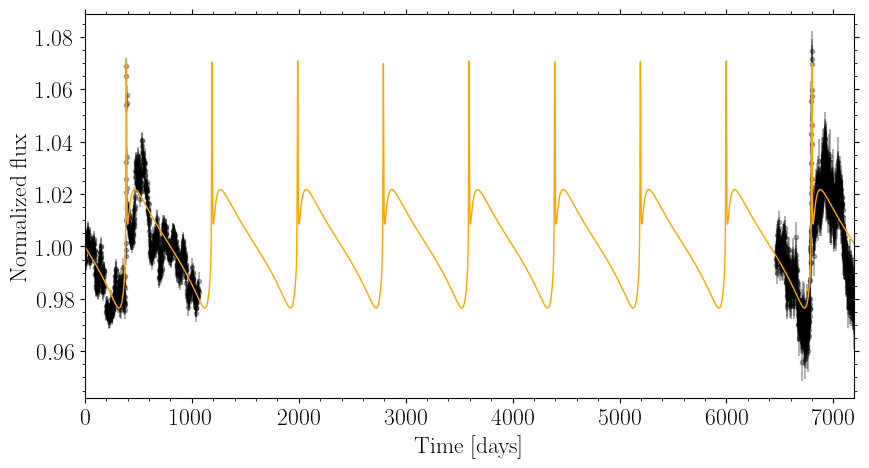

In [8]:
# Combine datasets
df = pd.concat((df_kepler, df_plato))
time = df.time.to_numpy()
flux = df.flux.to_numpy()

# Load default model priors
priors_DM  = bs.model_priors(params, model='DM') 
priors_Q   = bs.model_priors(params, model='Q',   flux=flux) 
priors_QDM = bs.model_priors(params, model='QDM', flux=flux) 

# Generate relativistic Spikey model
params = smbhb.model_params()
params.sigma = 0 
params.seed  = params.seed
model = smbhb.model(params)
tm = np.arange(df.time.iloc[0], df.time.iloc[-1], 1)
dm = model.light_curve(tm, df=True)

# Plot merged light curves
fig, ax = pt.plot_lc(df, dm, cm=cm, lw=1, alpha=0.3);

---
### 1.1. Model Q
```
INFO:jaxns:Number of Markov-chains set to: 2000
Running over 6 devices.
--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 8639058
samples: 33066
phantom samples: 0
likelihood evals / sample: 261.3
phantom fraction (%): 0.0%
--------
logZ=6460.594 +- 0.07
max(logL)=6468.803
H=-6.71
ESS=3255
--------
mean: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
mean: 0.996 +- 0.0072 | 0.9876 / 0.9964 / 1.0045 | 0.9964 | 0.9964
--------
sigma: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
sigma: 0.019 +- 0.0038 | 0.015 / 0.0183 / 0.0237 | 0.0168 | 0.0168
--------
tau: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
tau: 153.0 +- 71.0 | 90.0 / 136.0 / 230.0 | 114.0 | 114.0
--------
CPU times: user 5h 1min 56s, sys: 4min 40s, total: 5h 6min 36s
Wall time: 1h 2min 18s

```

In [9]:
filename = rdir / 'spikey_combined_jaxns_3yr2yr24h_Q.npy'

In [20]:
# %%time
# result = bs.run_jaxns(
#     df, params, priors_Q, 
#     build_mean=None, 
#     build_kernel=bs.drw_kernel, 
#     ofile=filename
# )

In [11]:
result = ut.load_result(filename)

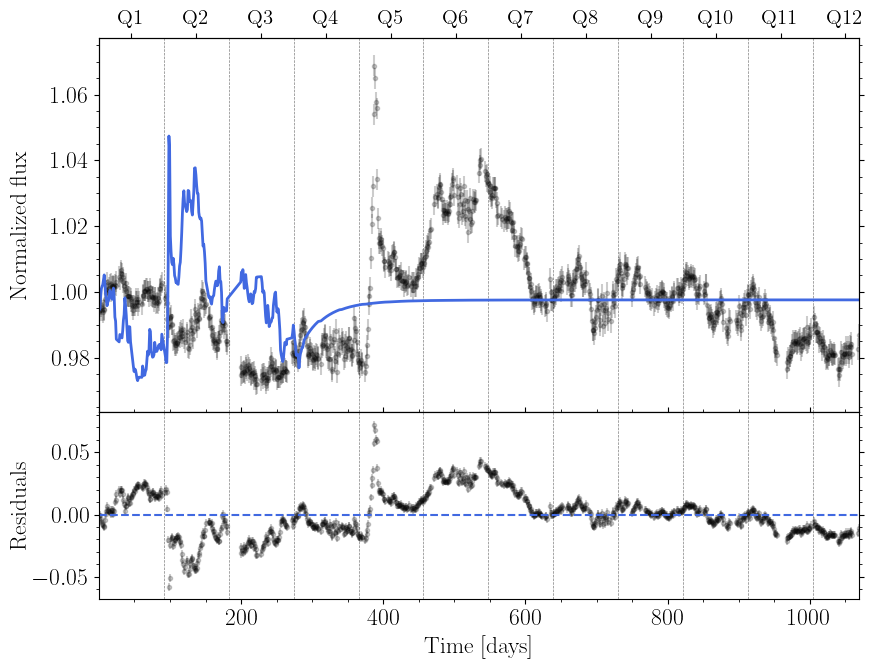

In [118]:
dm = bs.model_lightcurve_drw(time, result)
dm_kepler = dm.loc[:df_kepler.shape[0]-1]
# dm_plato  = dm[dm.time > 1500]
fig, ax = pt.plot_result(df_kepler, dm_kepler, Q0=1)
# fig = pt.plot_corner(result, best_params='mle', true_params=True);

# fig0, ax = pt.plot_result(df, dm, cm=c1, Q0=1, alpha=0.2)
# fig1 = pt.plot_corner(result, best_params='mle', true_params=True, color=c1);

# # Plot best-fit to Kepler light curve
# dm_kepler = bs.model_lightcurve_drw(df_kepler.time.to_numpy(), result)
# fig, ax = pt.plot_result(df_kepler, dm_kepler, Q0=1)
# # Plot best-fit to Plato light curve
# dm_plato = bs.model_lightcurve_drw(df_plato.time.to_numpy(), result)
# fig, ax = pt.plot_result(df_plato, dm_plato, Q0=1)

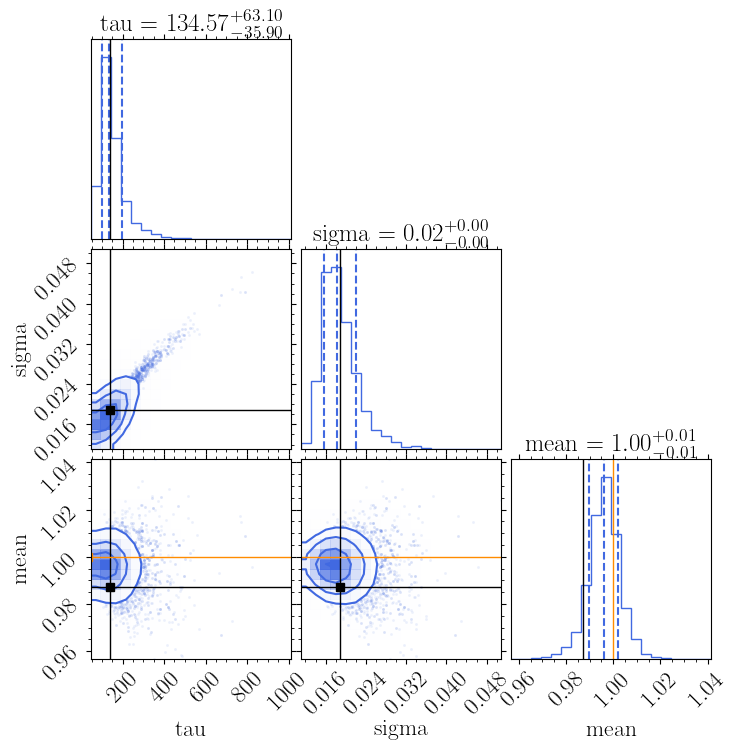

In [12]:
# Plot coner for combined model
fig = pt.plot_corner(result, best_params='mle', true_params=True);

In [13]:
# Print percentiles for latex
ut.get_percentiles(result, latex=True);

tau : pmx { 134.56696 }{ -35.89881 }{ 63.09759 }
sigma : pmx { 0.01822 }{ -0.00259 }{ 0.00379 }
mean : pmx { 0.99613 }{ -0.00638 }{ 0.00595 }


---
### 1.2. Model DM
```
INFO:jaxns:Number of Markov-chains set to: 2000
Running over 6 devices.
--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 108071628
samples: 95190
phantom samples: 0
likelihood evals / sample: 1135.3
phantom fraction (%): 0.0%
--------
logZ=4561.7 +- 0.18
max(logL)=4612.31
H=-45.58
ESS=5095
--------
L: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
L: 0.6181 +- 0.0095 | 0.6118 / 0.618 / 0.6247 | 0.6056 | 0.6056
--------
P: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
P: 1.143688 +- 4.2e-05 | 1.143636 / 1.143688 / 1.143742 | 1.143687 | 1.143687
--------
alpha: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
alpha: 0.967 +- 0.042 | 0.909 / 0.966 / 1.017 | 0.86 | 0.86
--------
e: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
e: 0.4565 +- 0.0055 | 0.4494 / 0.4568 / 0.4626 | 0.4581 | 0.4581
--------
i: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
i: 83.92 +- 0.13 | 83.74 / 83.94 / 84.07 | 83.98 | 83.98
--------
logM1: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
logM1: 7.316 +- 0.022 | 7.29 / 7.311 / 7.346 | 7.317 | 7.317
--------
logM2: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
logM2: 6.945 +- 0.031 | 6.908 / 6.944 / 6.982 | 6.955 | 6.955
--------
t0: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
t0: 1.0463 +- 0.001 | 1.045 / 1.0462 / 1.0477 | 1.0462 | 1.0462
--------
w: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
w: 81.5 +- 2.6 | 80.9 / 81.5 / 82.1 | 81.4 | 81.4
--------
CPU times: user 1d 1h 41min 22s, sys: 9min 16s, total: 1d 1h 50min 38s
Wall time: 4h 18min 20s

```

In [14]:
filename = rdir / 'spikey_combined_jaxns_3yr2yr24h_DM.npy'

In [22]:
# %%time
# result = bs.run_jaxns(
#     df, params, priors_DM, 
#     build_mean=bs.smbhb_mean_builder,
#     build_kernel=None, 
#     ofile=filename
# )

In [23]:
result = ut.load_result(filename)

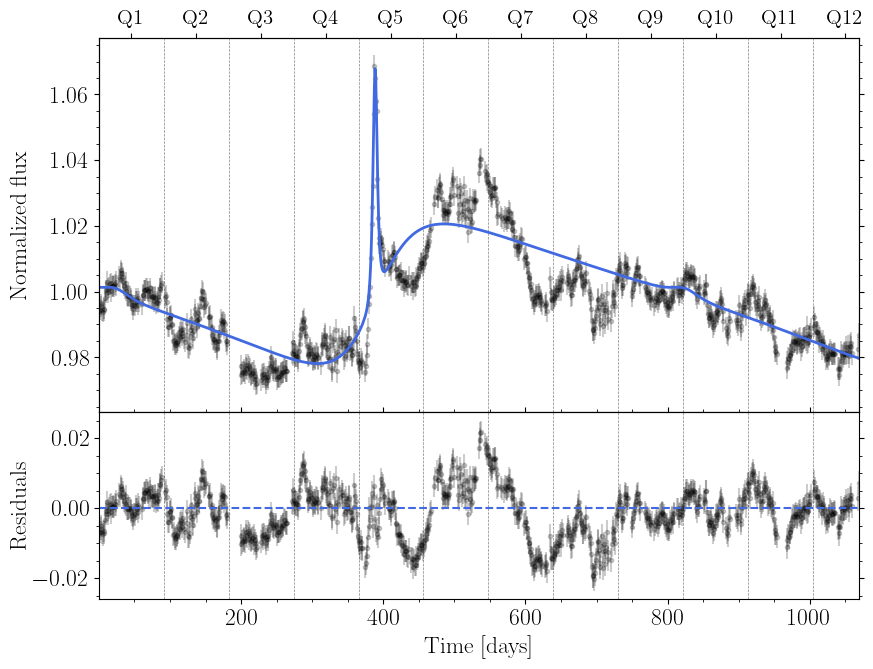

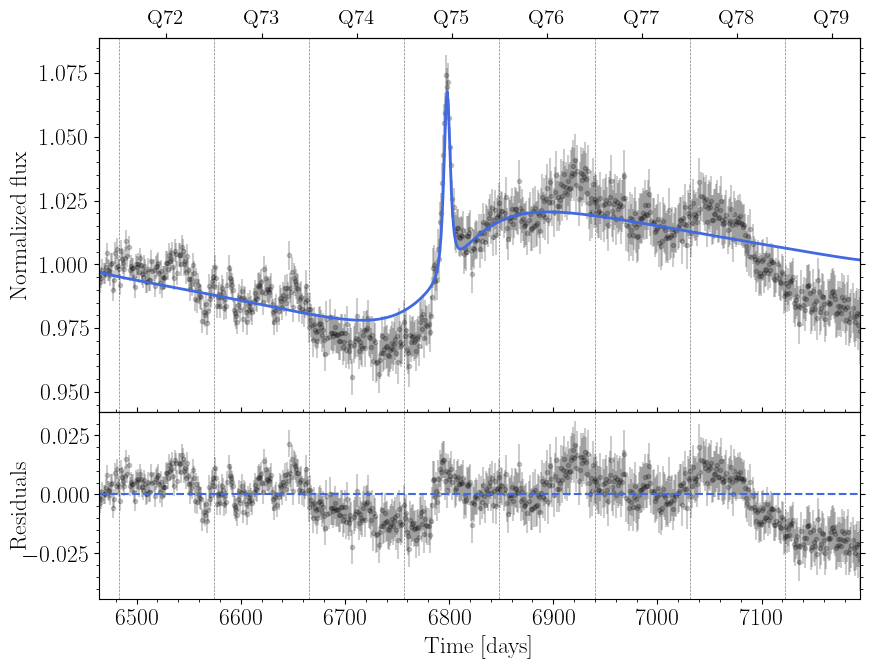

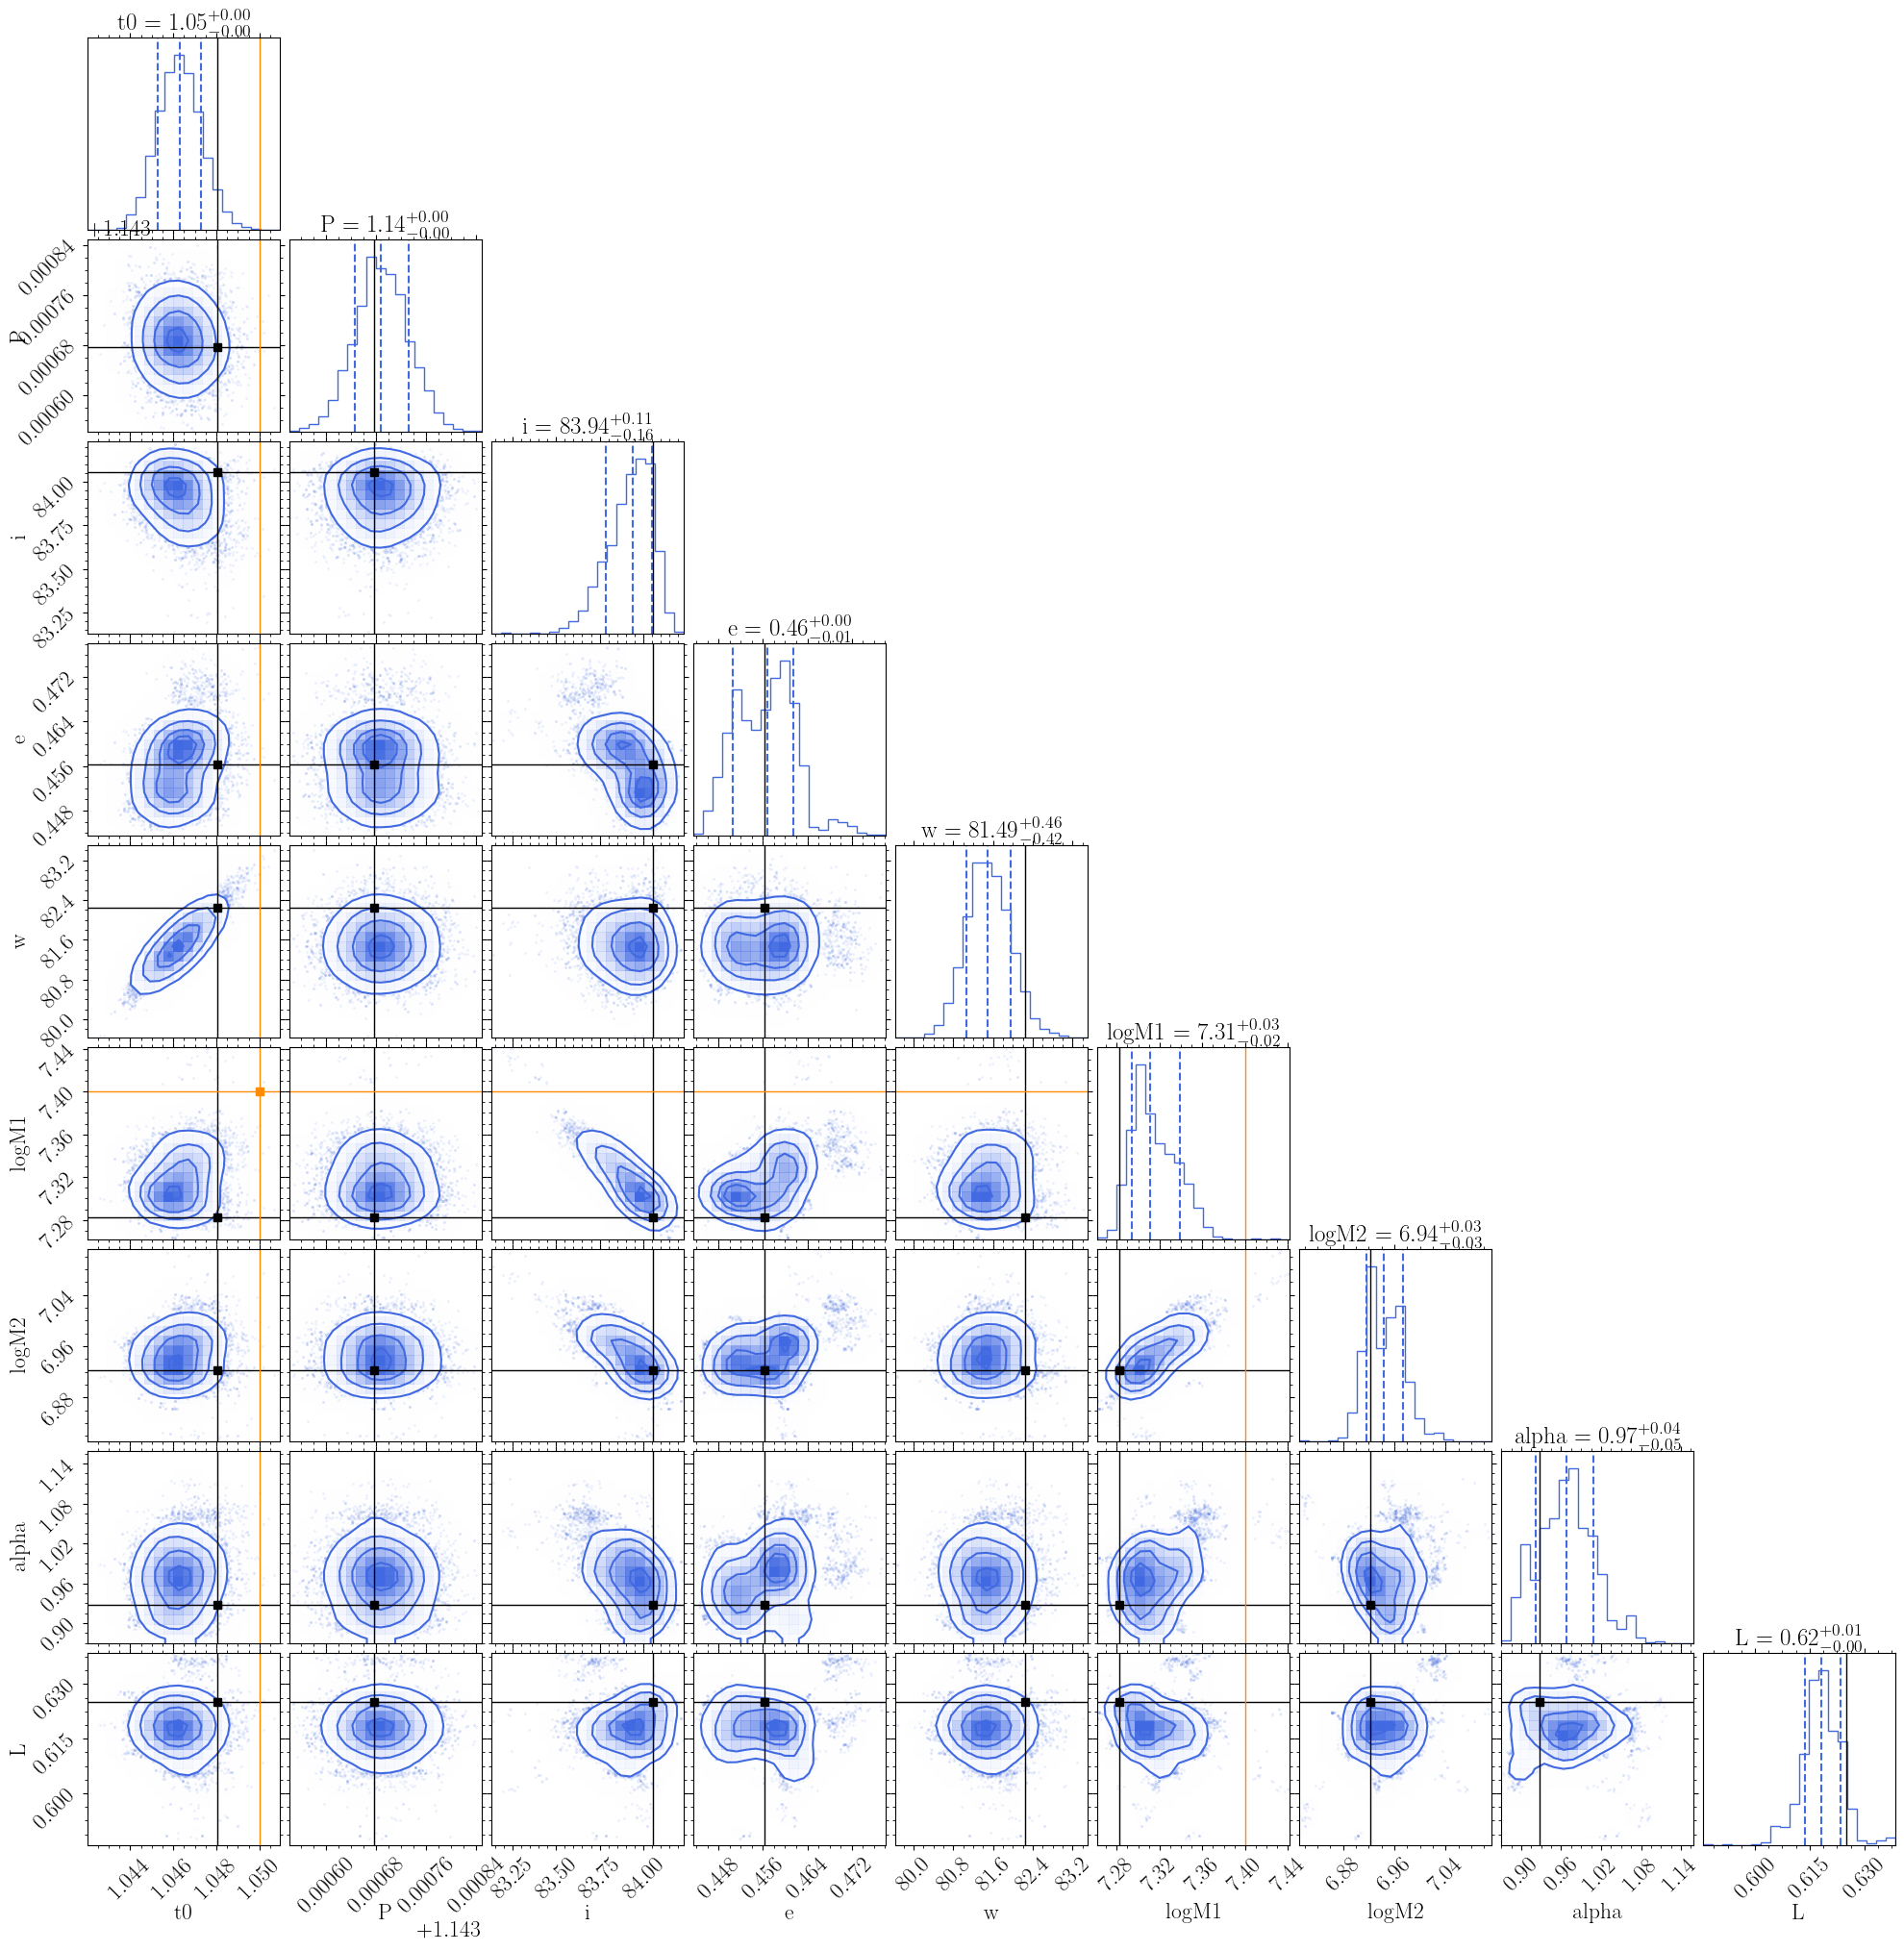

In [17]:
# Plot best-fit to Kepler light curve
dm_kepler = smbhb.model_lightcurve(df_kepler.time.to_numpy(), result['likelihood']['mle'])
fig, ax = pt.plot_result(df_kepler, dm_kepler, Q0=1)
# Plot best-fit to Plato light curve
dm_plato = smbhb.model_lightcurve(df_plato.time.to_numpy(), result['likelihood']['mle'])
fig, ax = pt.plot_result(df_plato, dm_plato, Q0=1)
# Plot coner for combined model
fig = pt.plot_corner(result, best_params='mle', true_params=True);

In [21]:
# # Resolve bimodality in w
# clusters_w = bs.get_posterior_clusters(df, result, param_cluster='w', n_components=2)
# result_w0 = clusters_w[0]
# result_w1 = clusters_w[1]
# fig = pt.plot_corner(result_w0, best_params='mle', true_params=True, color=c0)
# fig = pt.plot_corner(result_w1, best_params='mle', true_params=True, color=c1)

In [24]:
# Print percentiles for latex
ut.get_percentiles(result, latex=True);

t0 : pmx { 1.04628 }{ -0.00099 }{ 0.00100 }
P : pmx { 1.14369 }{ -0.00004 }{ 0.00004 }
i : pmx { 83.94073 }{ -0.15556 }{ 0.10702 }
e : pmx { 0.45675 }{ -0.00615 }{ 0.00468 }
w : pmx { 81.49104 }{ -0.42325 }{ 0.46043 }
logM1 : pmx { 7.31108 }{ -0.01659 }{ 0.02804 }
logM2 : pmx { 6.94368 }{ -0.02787 }{ 0.02977 }
alpha : pmx { 0.96756 }{ -0.04541 }{ 0.04133 }
L : pmx { 0.61820 }{ -0.00455 }{ 0.00539 }


---
### 1.3. Model QDM
```
INFO:jaxns:Number of Markov-chains set to: 2000
Running over 6 devices.
--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 99688566
samples: 77154
phantom samples: 0
likelihood evals / sample: 1292.1
phantom fraction (%): 0.0%
--------
logZ=6658.36 +- 0.16
max(logL)=6696.84
H=-33.54
ESS=5087
--------
L: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
L: 0.529 +- 0.051 | 0.507 / 0.522 / 0.535 | 0.535 | 0.535
--------
P: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
P: 3.02 +- 0.19 | 3.05 / 3.05 / 3.05 | 3.05 | 3.05
--------
alpha: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
alpha: 2.34 +- 0.17 | 2.22 / 2.32 / 2.43 | 2.14 | 2.14
--------
e: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
e: 0.77 +- 0.029 | 0.757 / 0.767 / 0.782 | 0.792 | 0.792
--------
i: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
i: 79.4 +- 8.2 | 79.5 / 80.5 / 81.1 | 79.2 | 79.2
--------
logM1: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
logM1: 7.87 +- 0.24 | 7.78 / 7.84 / 7.94 | 7.91 | 7.91
--------
logM2: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
logM2: 6.786 +- 0.088 | 6.703 / 6.783 / 6.877 | 6.715 | 6.715
--------
sigma: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
sigma: 0.0137 +- 0.00087 | 0.01316 / 0.0136 / 0.01405 | 0.01322 | 0.01322
--------
t0: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
t0: 1.0455 +- 0.0058 | 1.0399 / 1.0452 / 1.0509 | 1.049 | 1.049
--------
tau: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
tau: 214.0 +- 23.0 | 205.0 / 211.0 / 218.0 | 213.0 | 213.0
--------
w: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
w: 79.0 +- 15.0 | 73.0 / 77.0 / 81.0 | 78.0 | 78.0
--------
CPU times: user 1d 15h 29min 33s, sys: 1h 7min 6s, total: 1d 16h 36min 39s
Wall time: 7h 53min 46s
```

In [9]:
filename = rdir / 'spikey_combined_jaxns_3yr2yr24h_QDM.npy'

In [14]:
# %%time 
# result = bs.run_jaxns(
#     df, params, priors_QDM, 
#     build_mean=bs.smbhb_mean_builder, 
#     build_kernel=bs.drw_kernel, 
#     ofile=filename
# )

In [11]:
result = ut.load_result(filename)

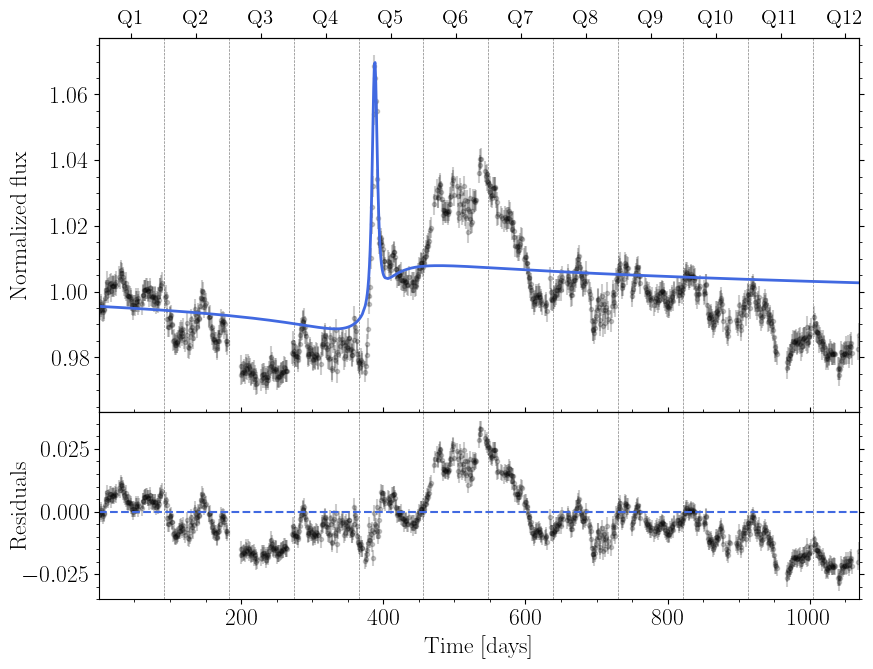

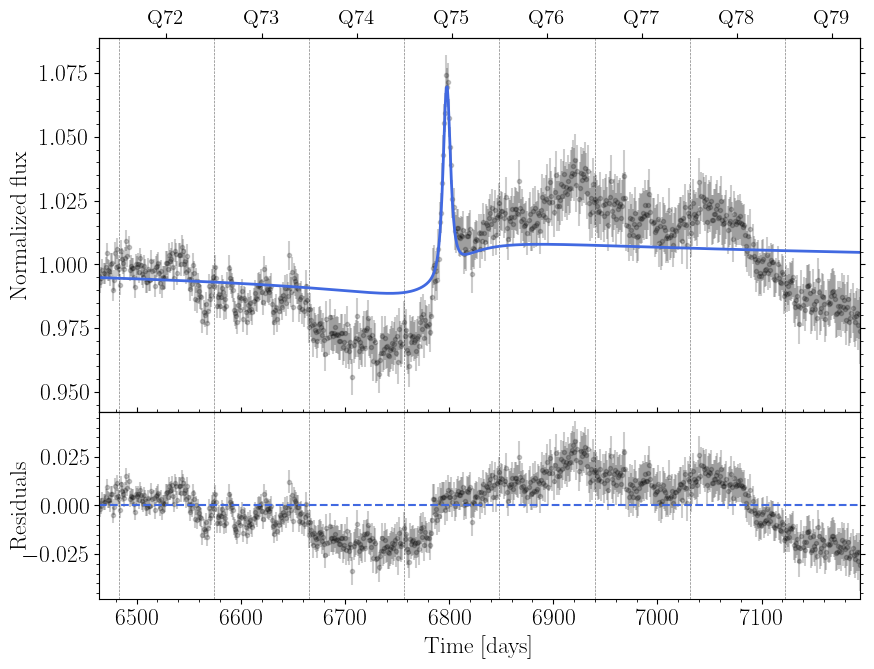

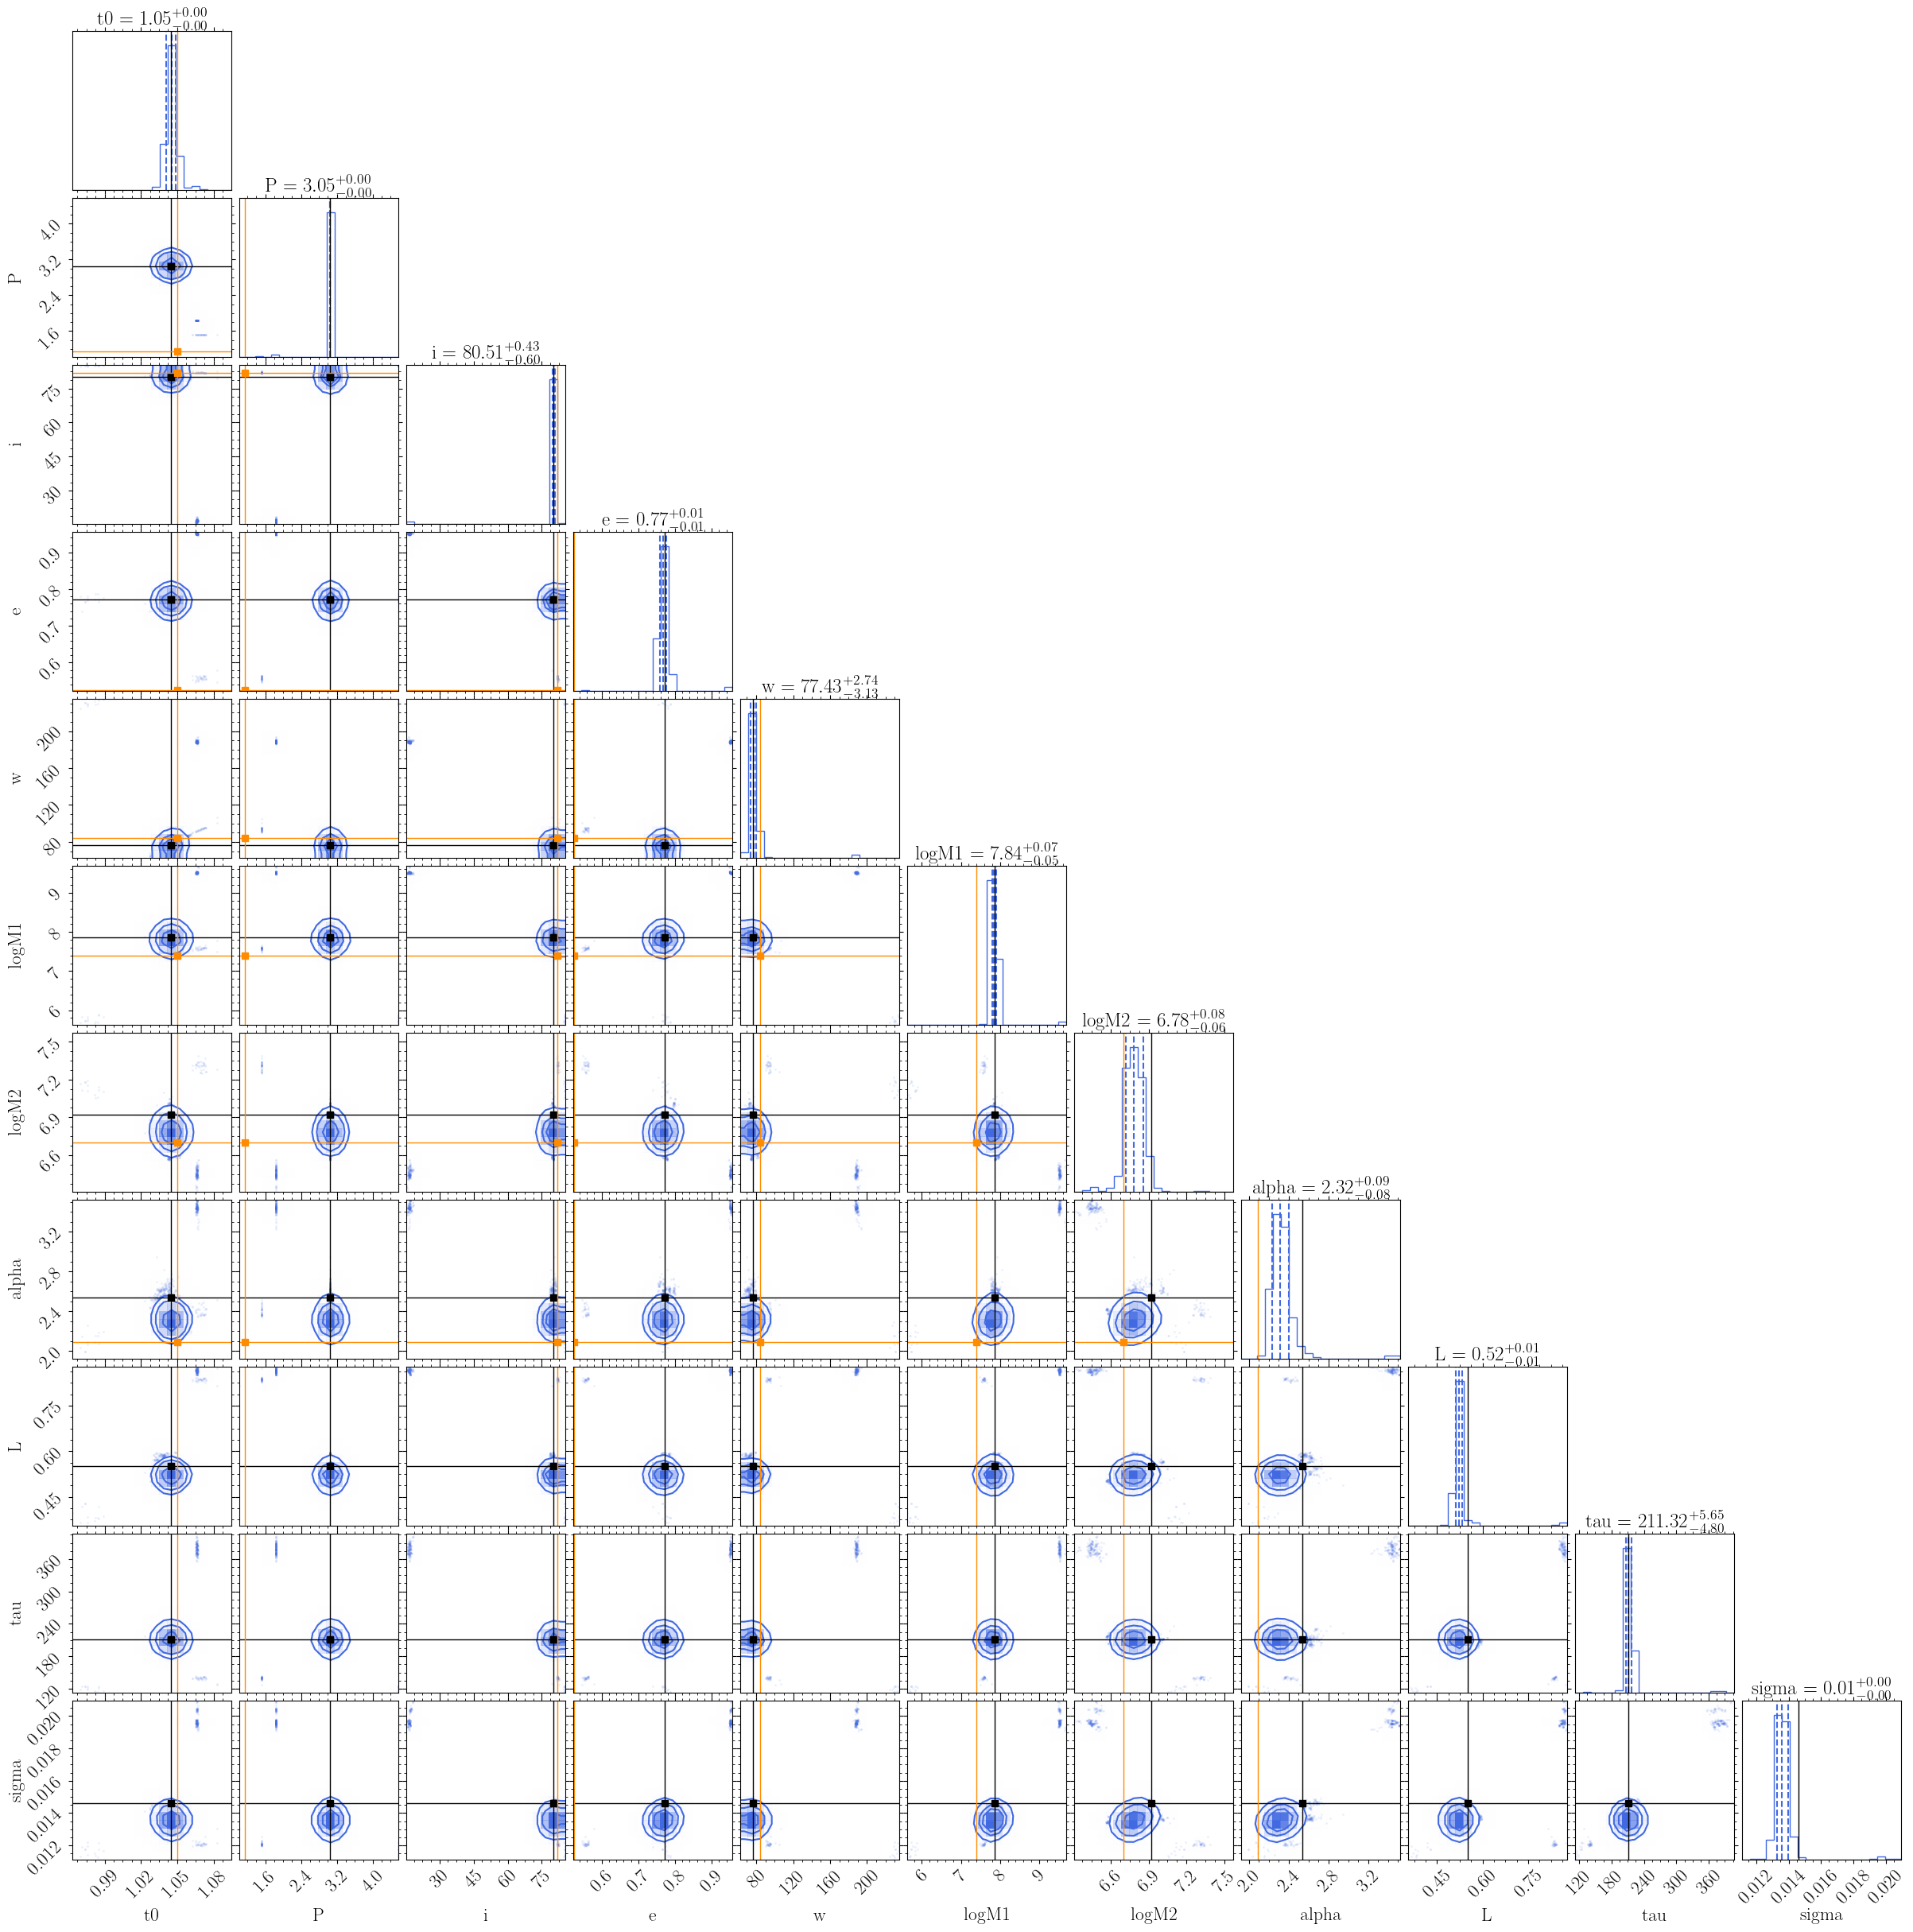

In [13]:
# Show results of QDM and DM model
# dm_QDM = bs.model_lightcurve_drw(time, result)
# dm_DM = smbhb.model_lightcurve(time, result['likelihood']['mle'])
# fig, ax = pt.plot_result(df, dm_QDM, Q0=Q0)
# ax[0].plot(dm_DM.time, dm_DM.flux, c=c0, lw=2)
# fig = pt.plot_corner(result, best_params='mle', true_params=True);

# Plot best-fit to Kepler light curve
dm_kepler = smbhb.model_lightcurve(df_kepler.time.to_numpy(), result['likelihood']['mle'])
fig, ax = pt.plot_result(df_kepler, dm_kepler, Q0=1)
# Plot best-fit to Plato light curve
dm_plato = smbhb.model_lightcurve(df_plato.time.to_numpy(), result['likelihood']['mle'])
fig, ax = pt.plot_result(df_plato, dm_plato, Q0=1)
# Plot coner for combined model
fig = pt.plot_corner(result, best_params='mle', true_params=True);

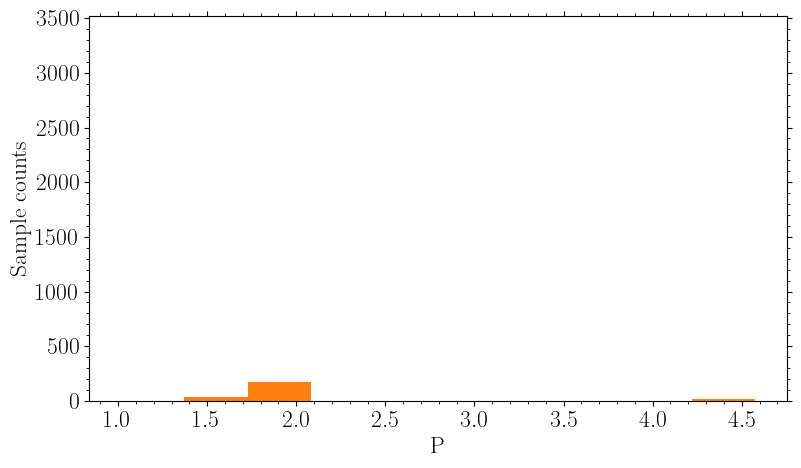

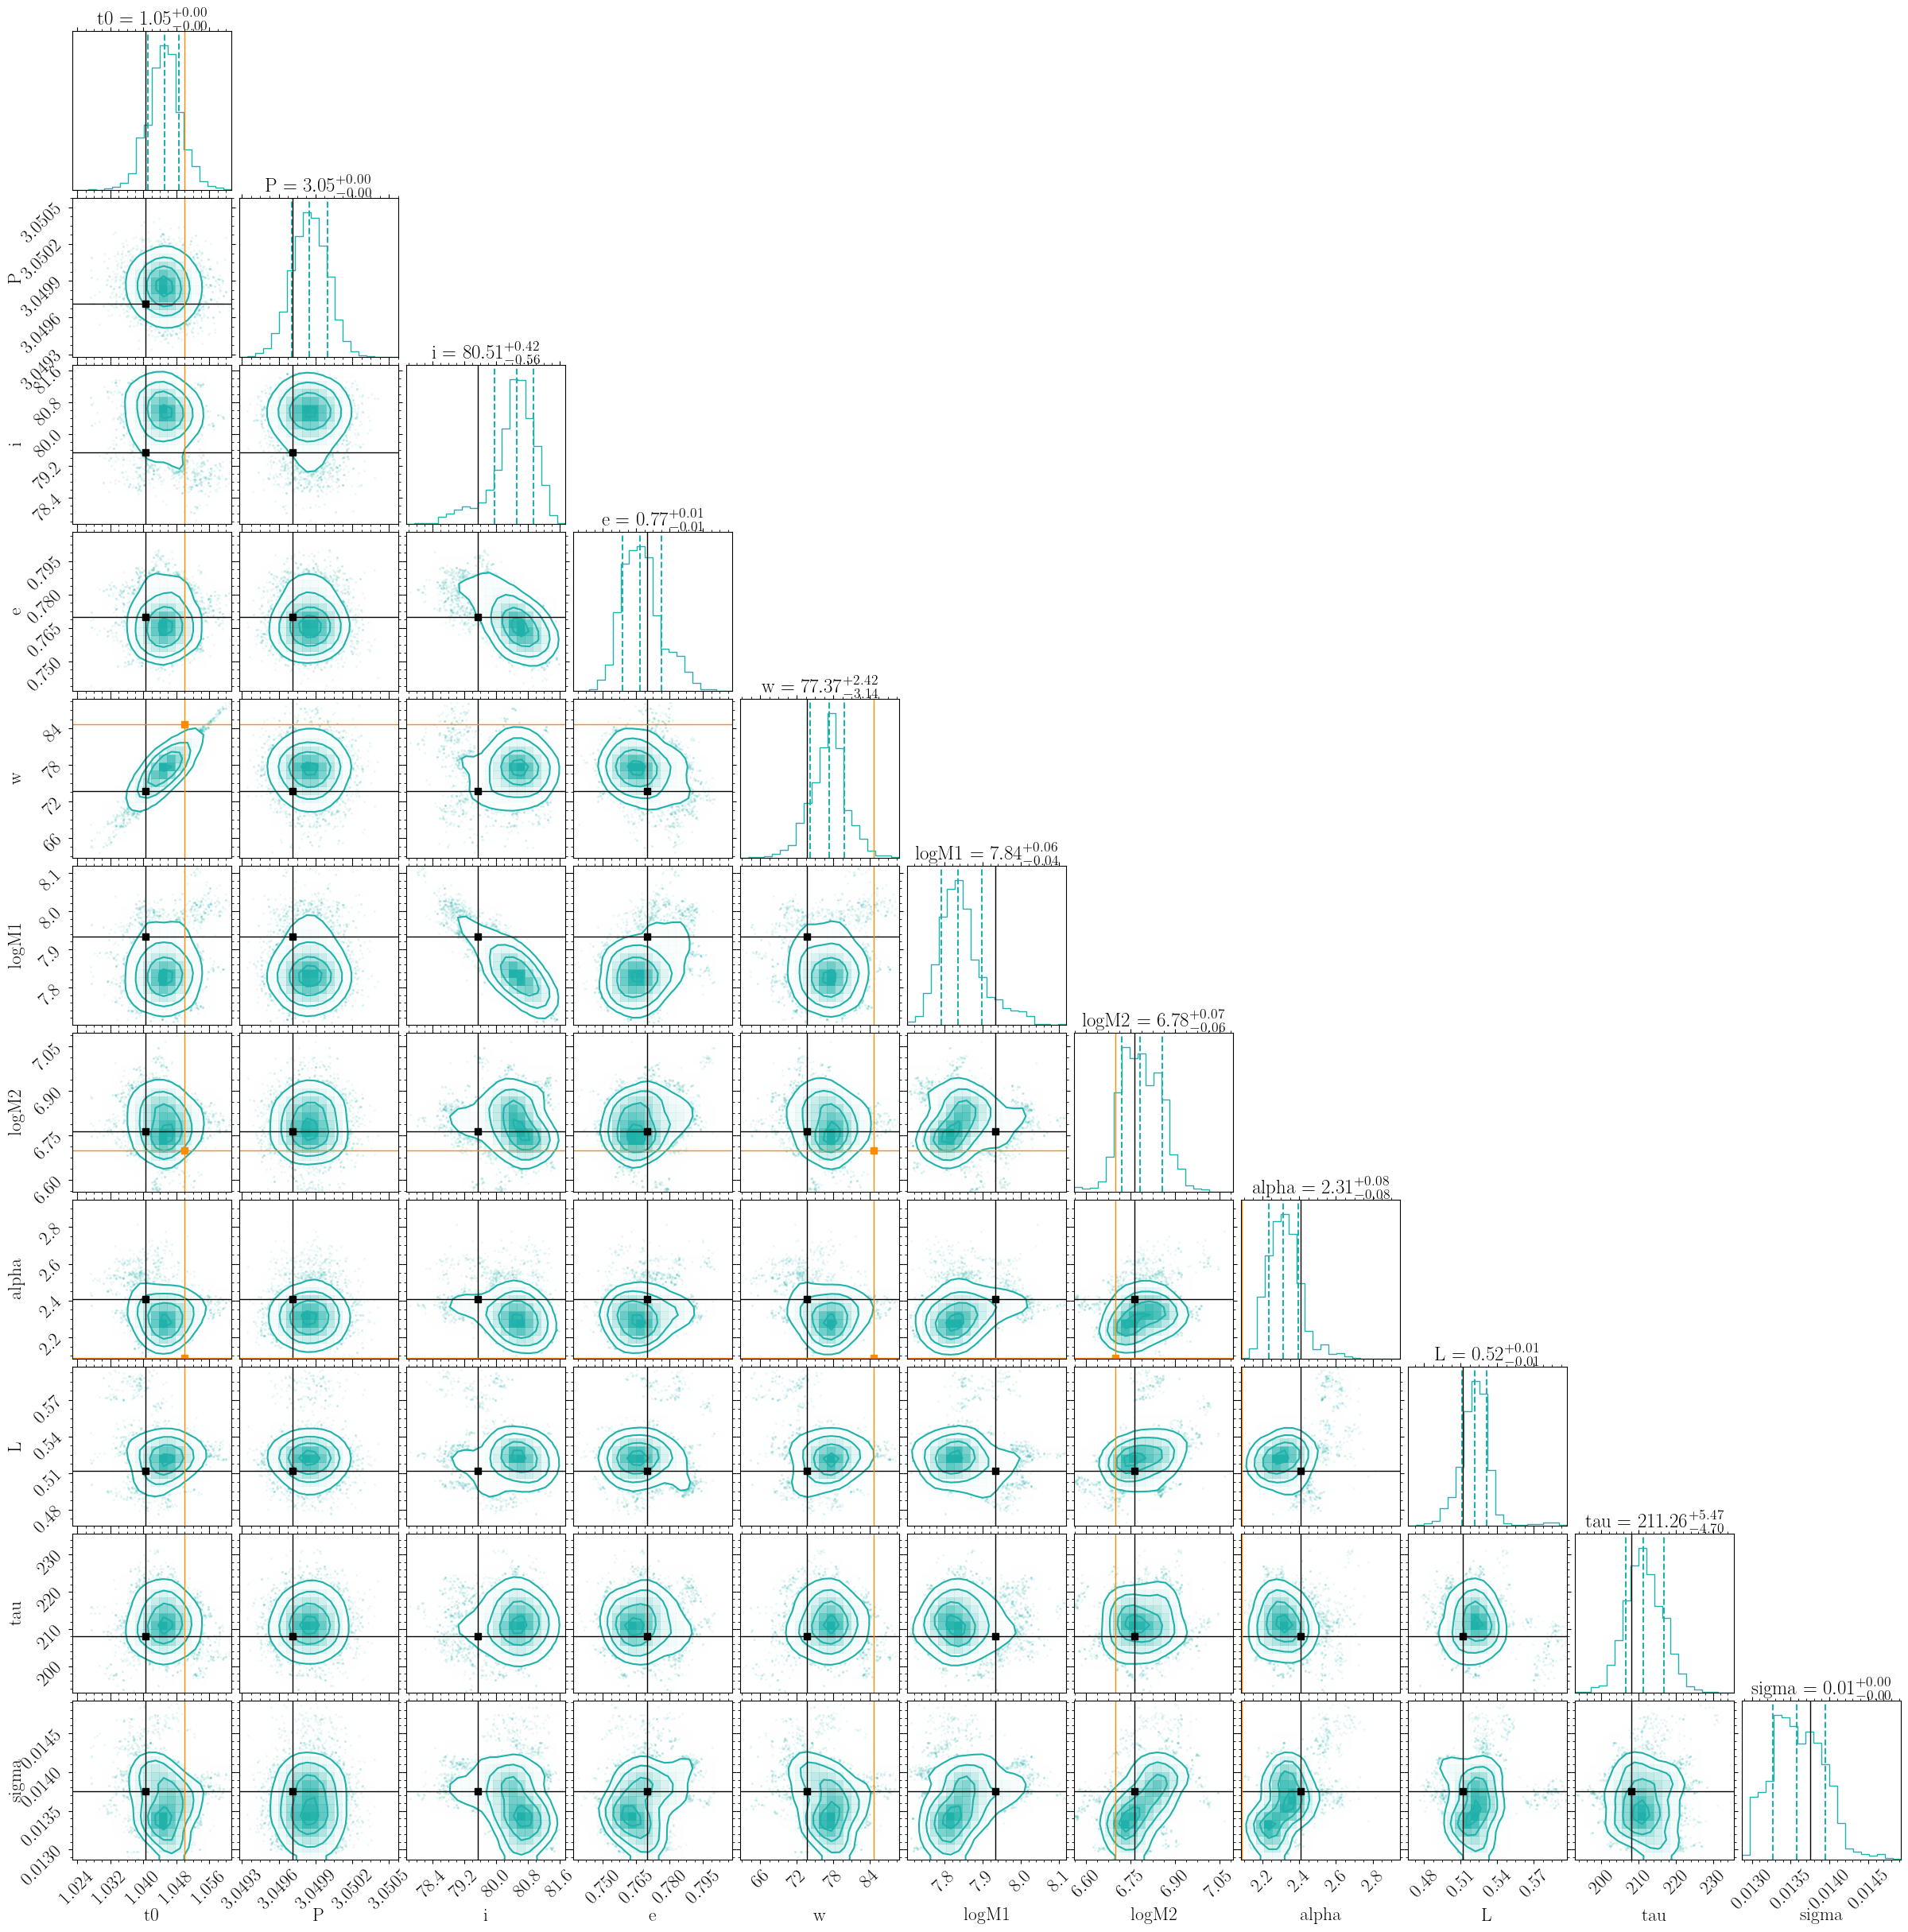

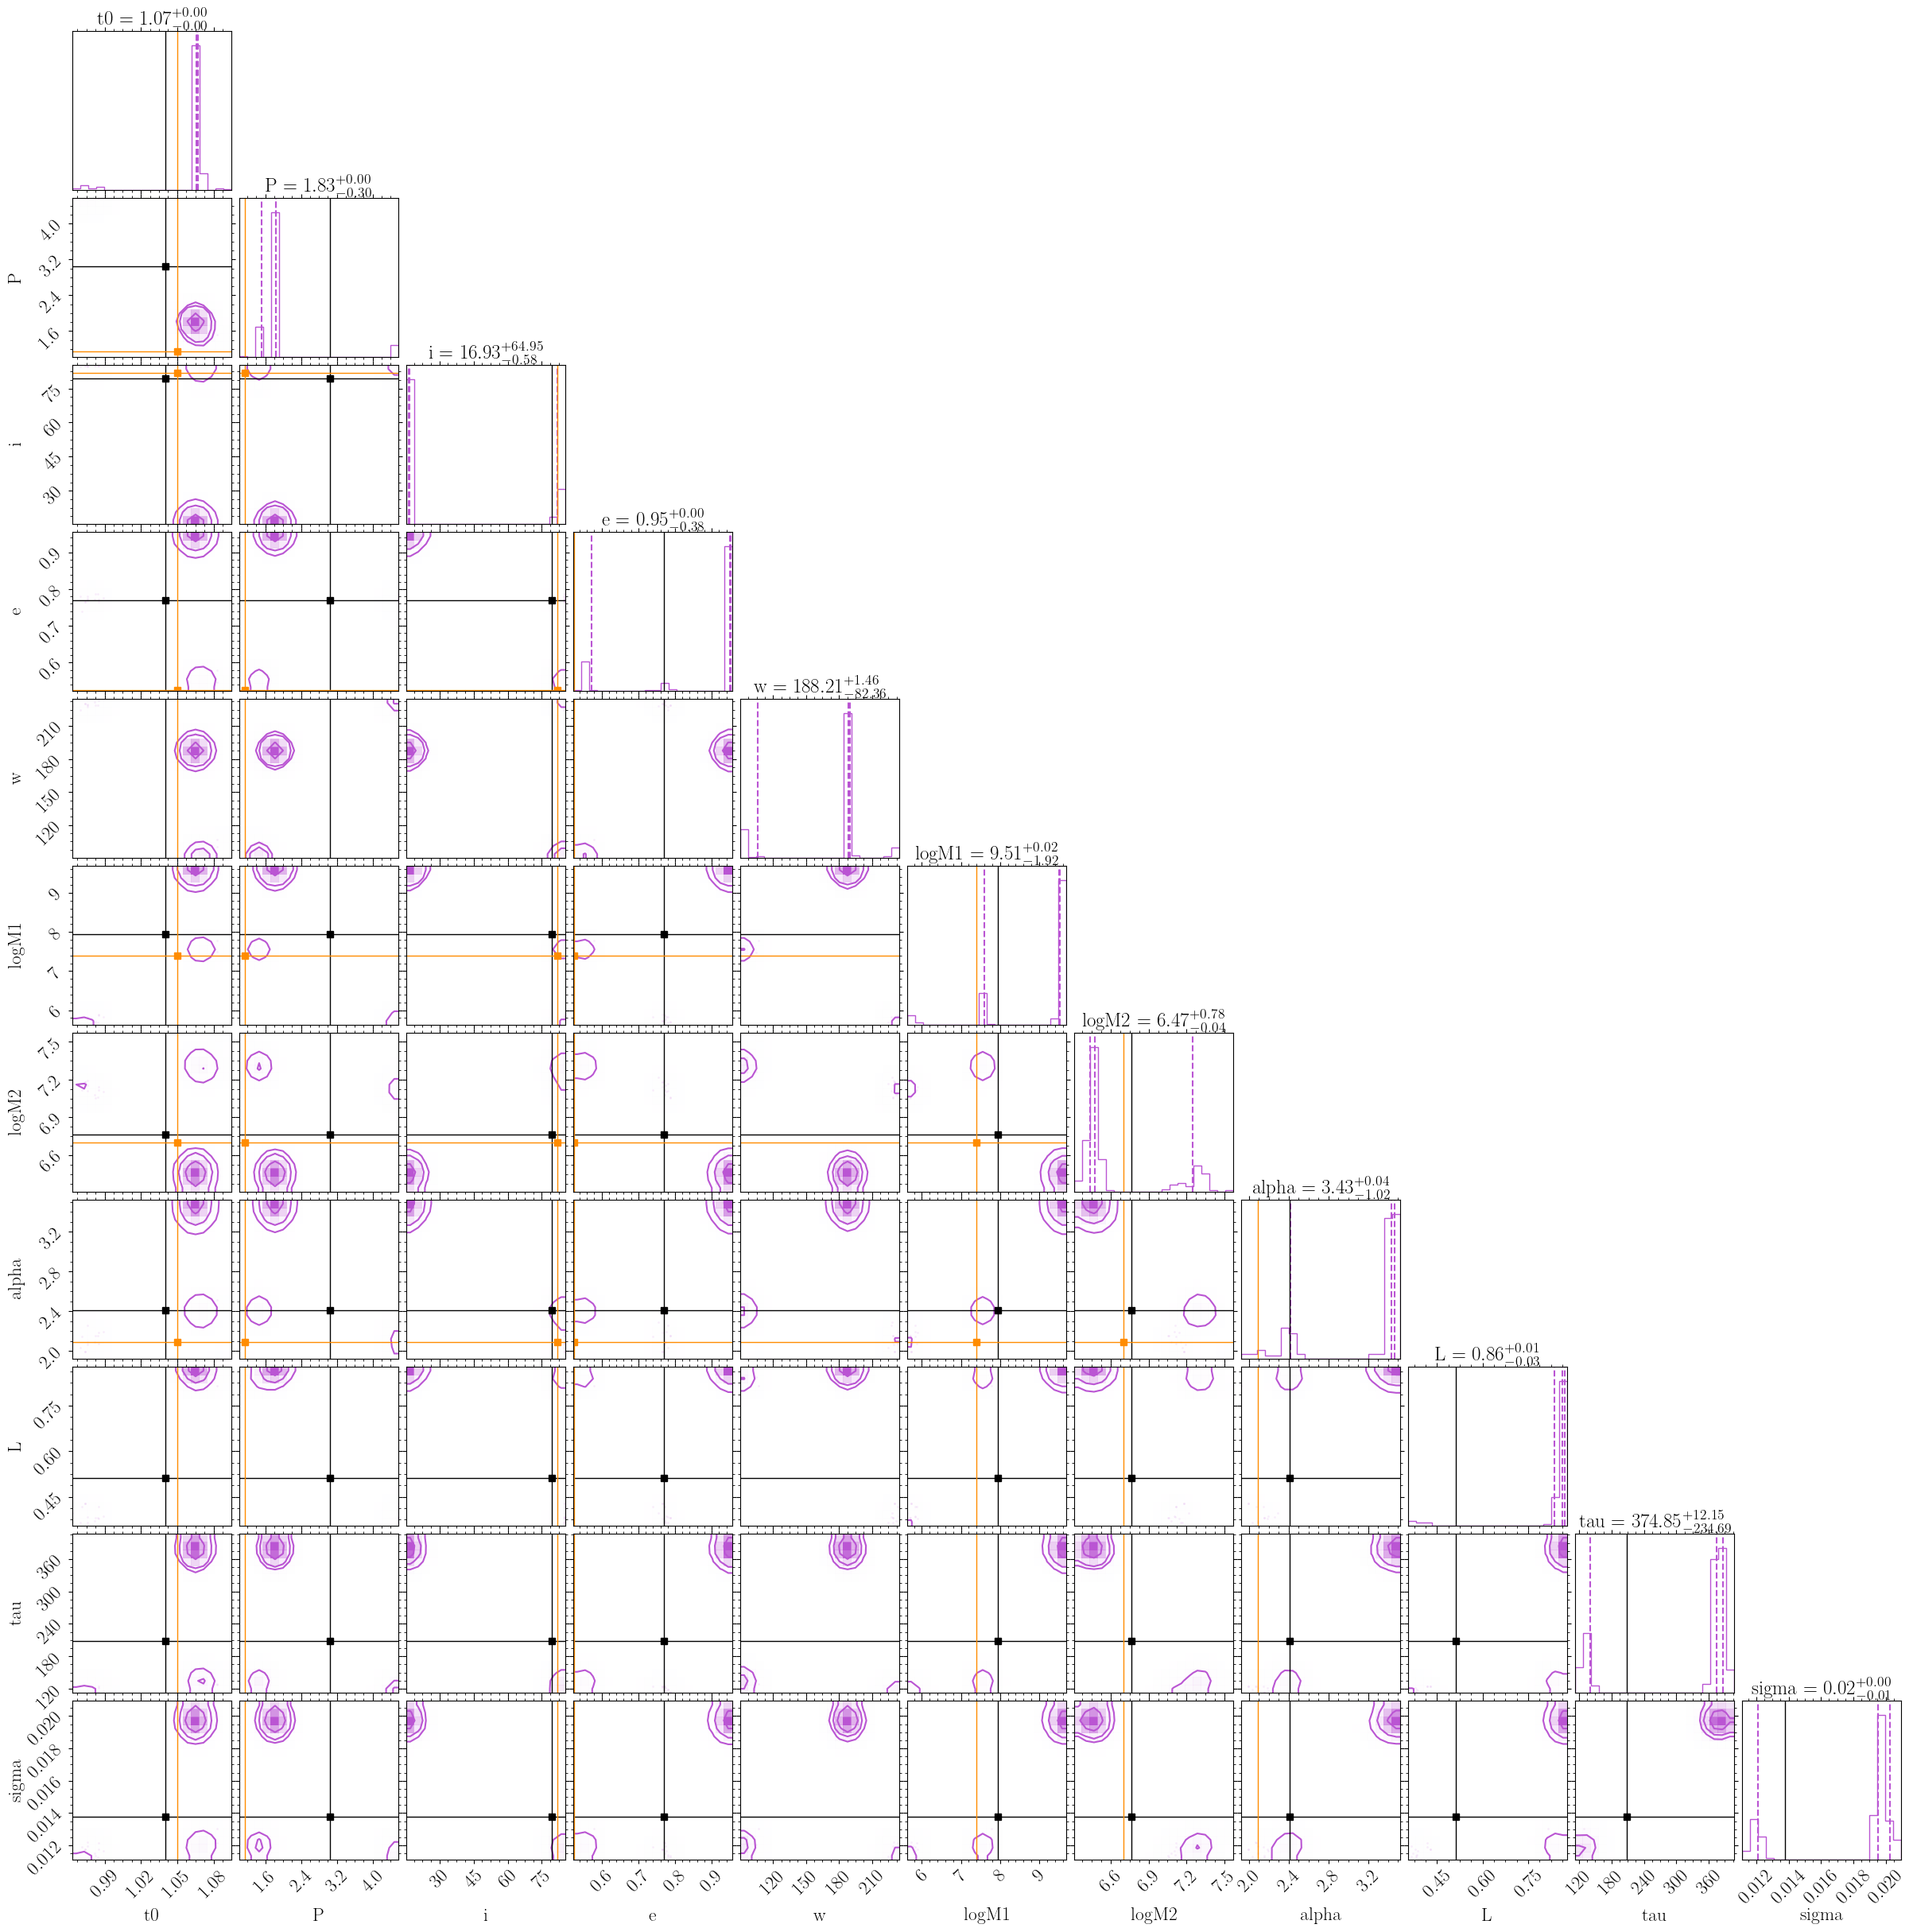

In [20]:
# Resolve bimodality in w
clusters_P = bs.get_posterior_clusters(df, result, param_cluster='P', n_components=2)
result_P0 = clusters_P[0]
result_P1 = clusters_P[1]
fig = pt.plot_corner(result_P0, best_params='mle', true_params=True, color=c0);
fig = pt.plot_corner(result_P1, best_params='mle', true_params=True, color=c1);

In [21]:
# Print percentiles for latex
ut.get_percentiles(result_P0, latex=True);

t0 : pmx { 1.04512 }{ -0.00400 }{ 0.00356 }
P : pmx { 3.04985 }{ -0.00014 }{ 0.00014 }
i : pmx { 80.51439 }{ -0.55676 }{ 0.42329 }
e : pmx { 0.76670 }{ -0.00794 }{ 0.00963 }
w : pmx { 77.36968 }{ -3.13732 }{ 2.41837 }
logM1 : pmx { 7.83633 }{ -0.04475 }{ 0.06242 }
logM2 : pmx { 6.78393 }{ -0.06297 }{ 0.07412 }
alpha : pmx { 2.31354 }{ -0.07901 }{ 0.08272 }
L : pmx { 0.52172 }{ -0.01068 }{ 0.00961 }
tau : pmx { 211.26484 }{ -4.69595 }{ 5.47103 }
sigma : pmx { 0.01358 }{ -0.00031 }{ 0.00037 }


---
## 2. *Kepler* + *Plato* 4-yr light curve
---

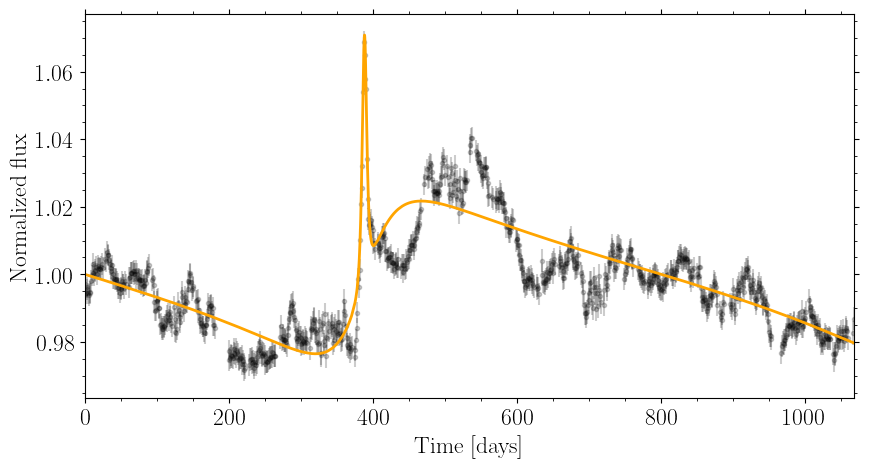

In [21]:
# Load Hu+2020 binned light curve of Spikey 
df_kepler = pd.read_feather(ddir / 'lc_spikey_kepler_smith2016.ftr')
Q0_kepler = 12

# Generate relativistic Spikey model
params = smbhb.model_params()
params.sigma = 0
params.t0 = 1.0544
model = smbhb.model(params)
dm_kepler = model.light_curve(df_kepler.time.to_numpy(), df=True)

# Create a 1-d binned light curve and plot
df_kepler = ut.bin_lc(df_kepler, bin_size=1)

# Plot light curve
fig, ax = pt.plot_lc(df_kepler, dm_kepler, cm=cm, alpha=0.2);

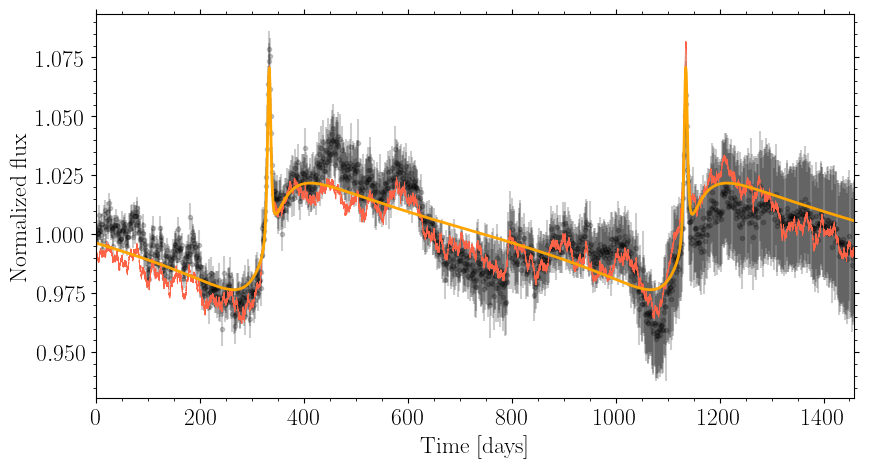

In [23]:
# Load Plato simulation and template of Spikey 
df_plato = pd.read_feather(ddir / 'lc_spikey_plato_fiducial.ftr')
dv_plato = pd.read_feather(ddir / 'lc_spikey_plato_template.ftr')
Q0_plato = 9

# Bin to 1-hour light curve 
df_plato = ut.bin_lc(df_plato, bin_size=1)

# Cut light curve to 2-year duration
# df_plato = df_plato[df_plato.time < 4*ut.year2day()]

# Generate relativistic Spikey model
params = smbhb.model_params()
params.t0    = 0.712
params.sigma = 0 
model = smbhb.model(params)
dm_plato = model.light_curve(df_plato.time.to_numpy(), df=True)

# Set first exposure to zero
t0_offset = df_plato.time.iloc[0]
df_plato.time -= t0_offset
dv_plato.time -= t0_offset
dm_plato.time -= t0_offset

# Secure mean level
mean = np.mean(df_plato.flux) - 1
df_plato.flux -= mean

# Plot light curve
fig, ax = pt.plot_lc(df_plato, dv_plato, cm=cv, lw=0.5)
ax.plot(dm_plato.time, dm_plato.flux, '-', c=cm, lw=2);

# Add offset to Plato light curve
t0_kepler = 1.05
t0_plato  = 1.195
df_plato.time += (t0_plato - t0_kepler) * ut.year2day()
df_plato.time += 8 * smbhb._period_observed(params.P, params.z) * ut.year2day()

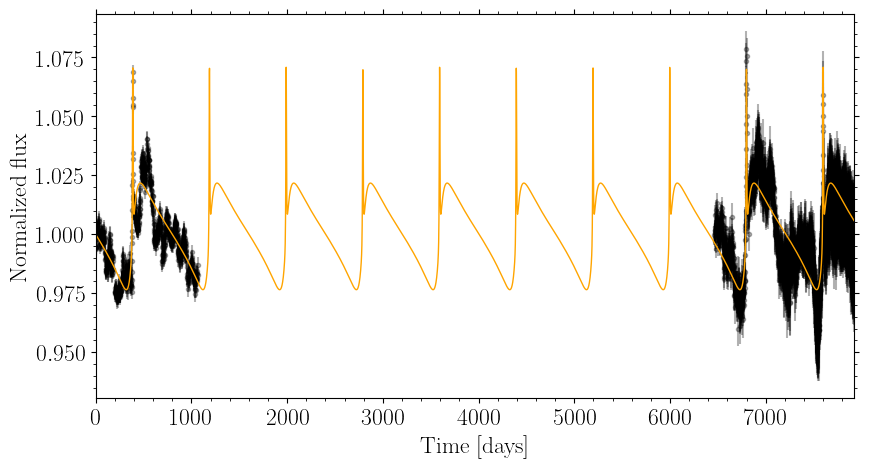

In [24]:
# Combine datasets
df = pd.concat((df_kepler, df_plato))
time = df.time.to_numpy()
flux = df.flux.to_numpy()

# Load default model priors
priors_DM  = bs.model_priors(params, model='DM') 
priors_Q   = bs.model_priors(params, model='Q',   flux=flux) 
priors_QDM = bs.model_priors(params, model='QDM', flux=flux)

# Generate relativistic Spikey model
params = smbhb.model_params()
params.sigma = 0 
params.seed  = params.seed
model = smbhb.model(params)
tm = np.arange(df.time.iloc[0], df.time.iloc[-1], 1)
dm = model.light_curve(tm, df=True)

# Plot merged light curves
fig, ax = pt.plot_lc(df, dm, cm=cm, lw=1, alpha=0.3);

---
### 1.1. Model Q
```
INFO:jaxns:Number of Markov-chains set to: 2000
Running over 6 devices.
--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 9173376
samples: 34068
phantom samples: 0
likelihood evals / sample: 269.3
phantom fraction (%): 0.0%
--------
logZ=8692.584 +- 0.071
max(logL)=8701.142
H=-6.99
ESS=3340
--------
mean: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
mean: 0.9976 +- 0.0058 | 0.9906 / 0.9977 / 1.0048 | 0.998 | 0.998
--------
sigma: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
sigma: 0.0177 +- 0.003 | 0.0145 / 0.0172 / 0.0214 | 0.016 | 0.016
--------
tau: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
tau: 138.0 +- 52.0 | 90.0 / 127.0 / 199.0 | 109.0 | 109.0
--------
CPU times: user 10h 40min 35s, sys: 7min 56s, total: 10h 48min 31s
Wall time: 2h 2min 44s
```

In [13]:
filename = rdir / 'spikey_combined_jaxns_3yr4yr24h_Q.npy'

In [15]:
# %%time
# result = bs.run_jaxns(
#     df, params, priors_Q, 
#     build_mean=None, 
#     build_kernel=bs.drw_kernel, 
#     ofile=filename
# )

In [16]:
result = ut.load_result(filename)

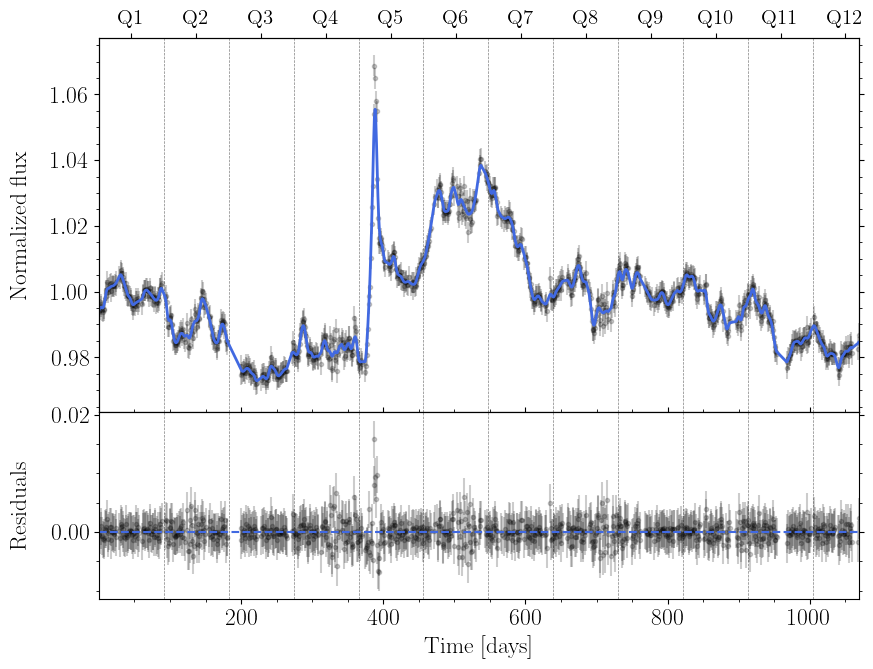

In [17]:
dm = bs.model_lightcurve_drw(time, result)
dm_kepler = dm.loc[:df_kepler.shape[0]-1]
fig, ax = pt.plot_result(df_kepler, dm_kepler, Q0=1)
fig = pt.plot_corner(result, best_params='mle', true_params=True);

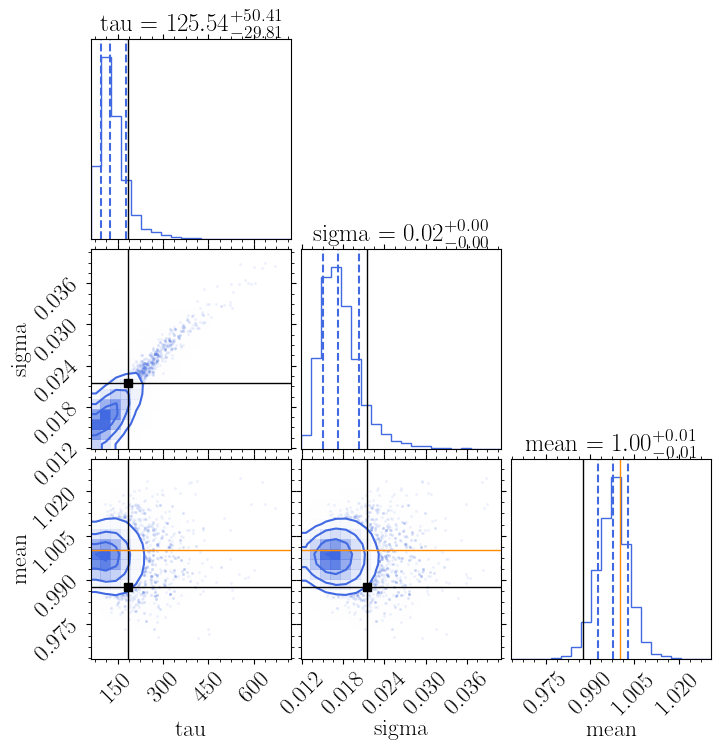

In [18]:
# Plot coner for combined model
fig = pt.plot_corner(result, best_params='mle', true_params=True);

In [19]:
# Print percentiles for latex
# ut.get_percentiles(result, latex=True);

---
### 1.2. Model DM


In [25]:
filename = rdir / 'spikey_combined_jaxns_3yr4yr24h_DM.npy'

In [1]:
%%time
result = bs.run_jaxns(
    df, params, priors_DM, 
    build_mean=bs.smbhb_mean_builder,
    build_kernel=None, 
    ofile=filename
)

In [23]:
result = ut.load_result(filename)

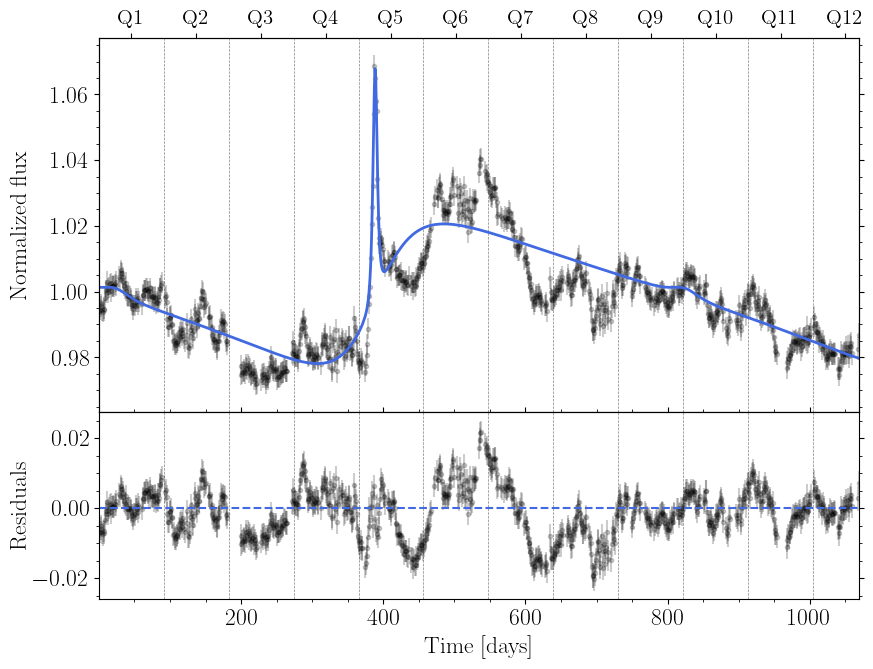

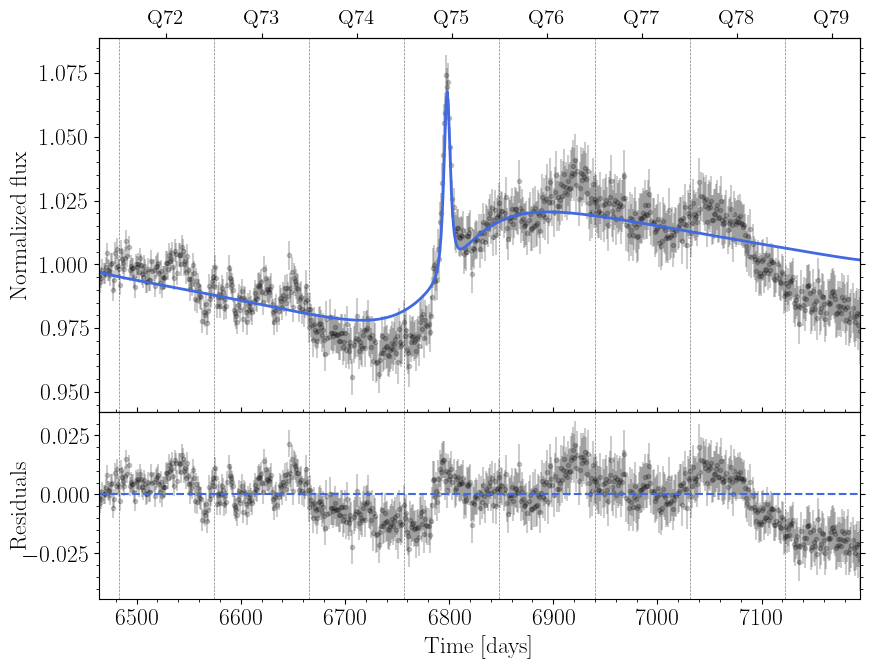

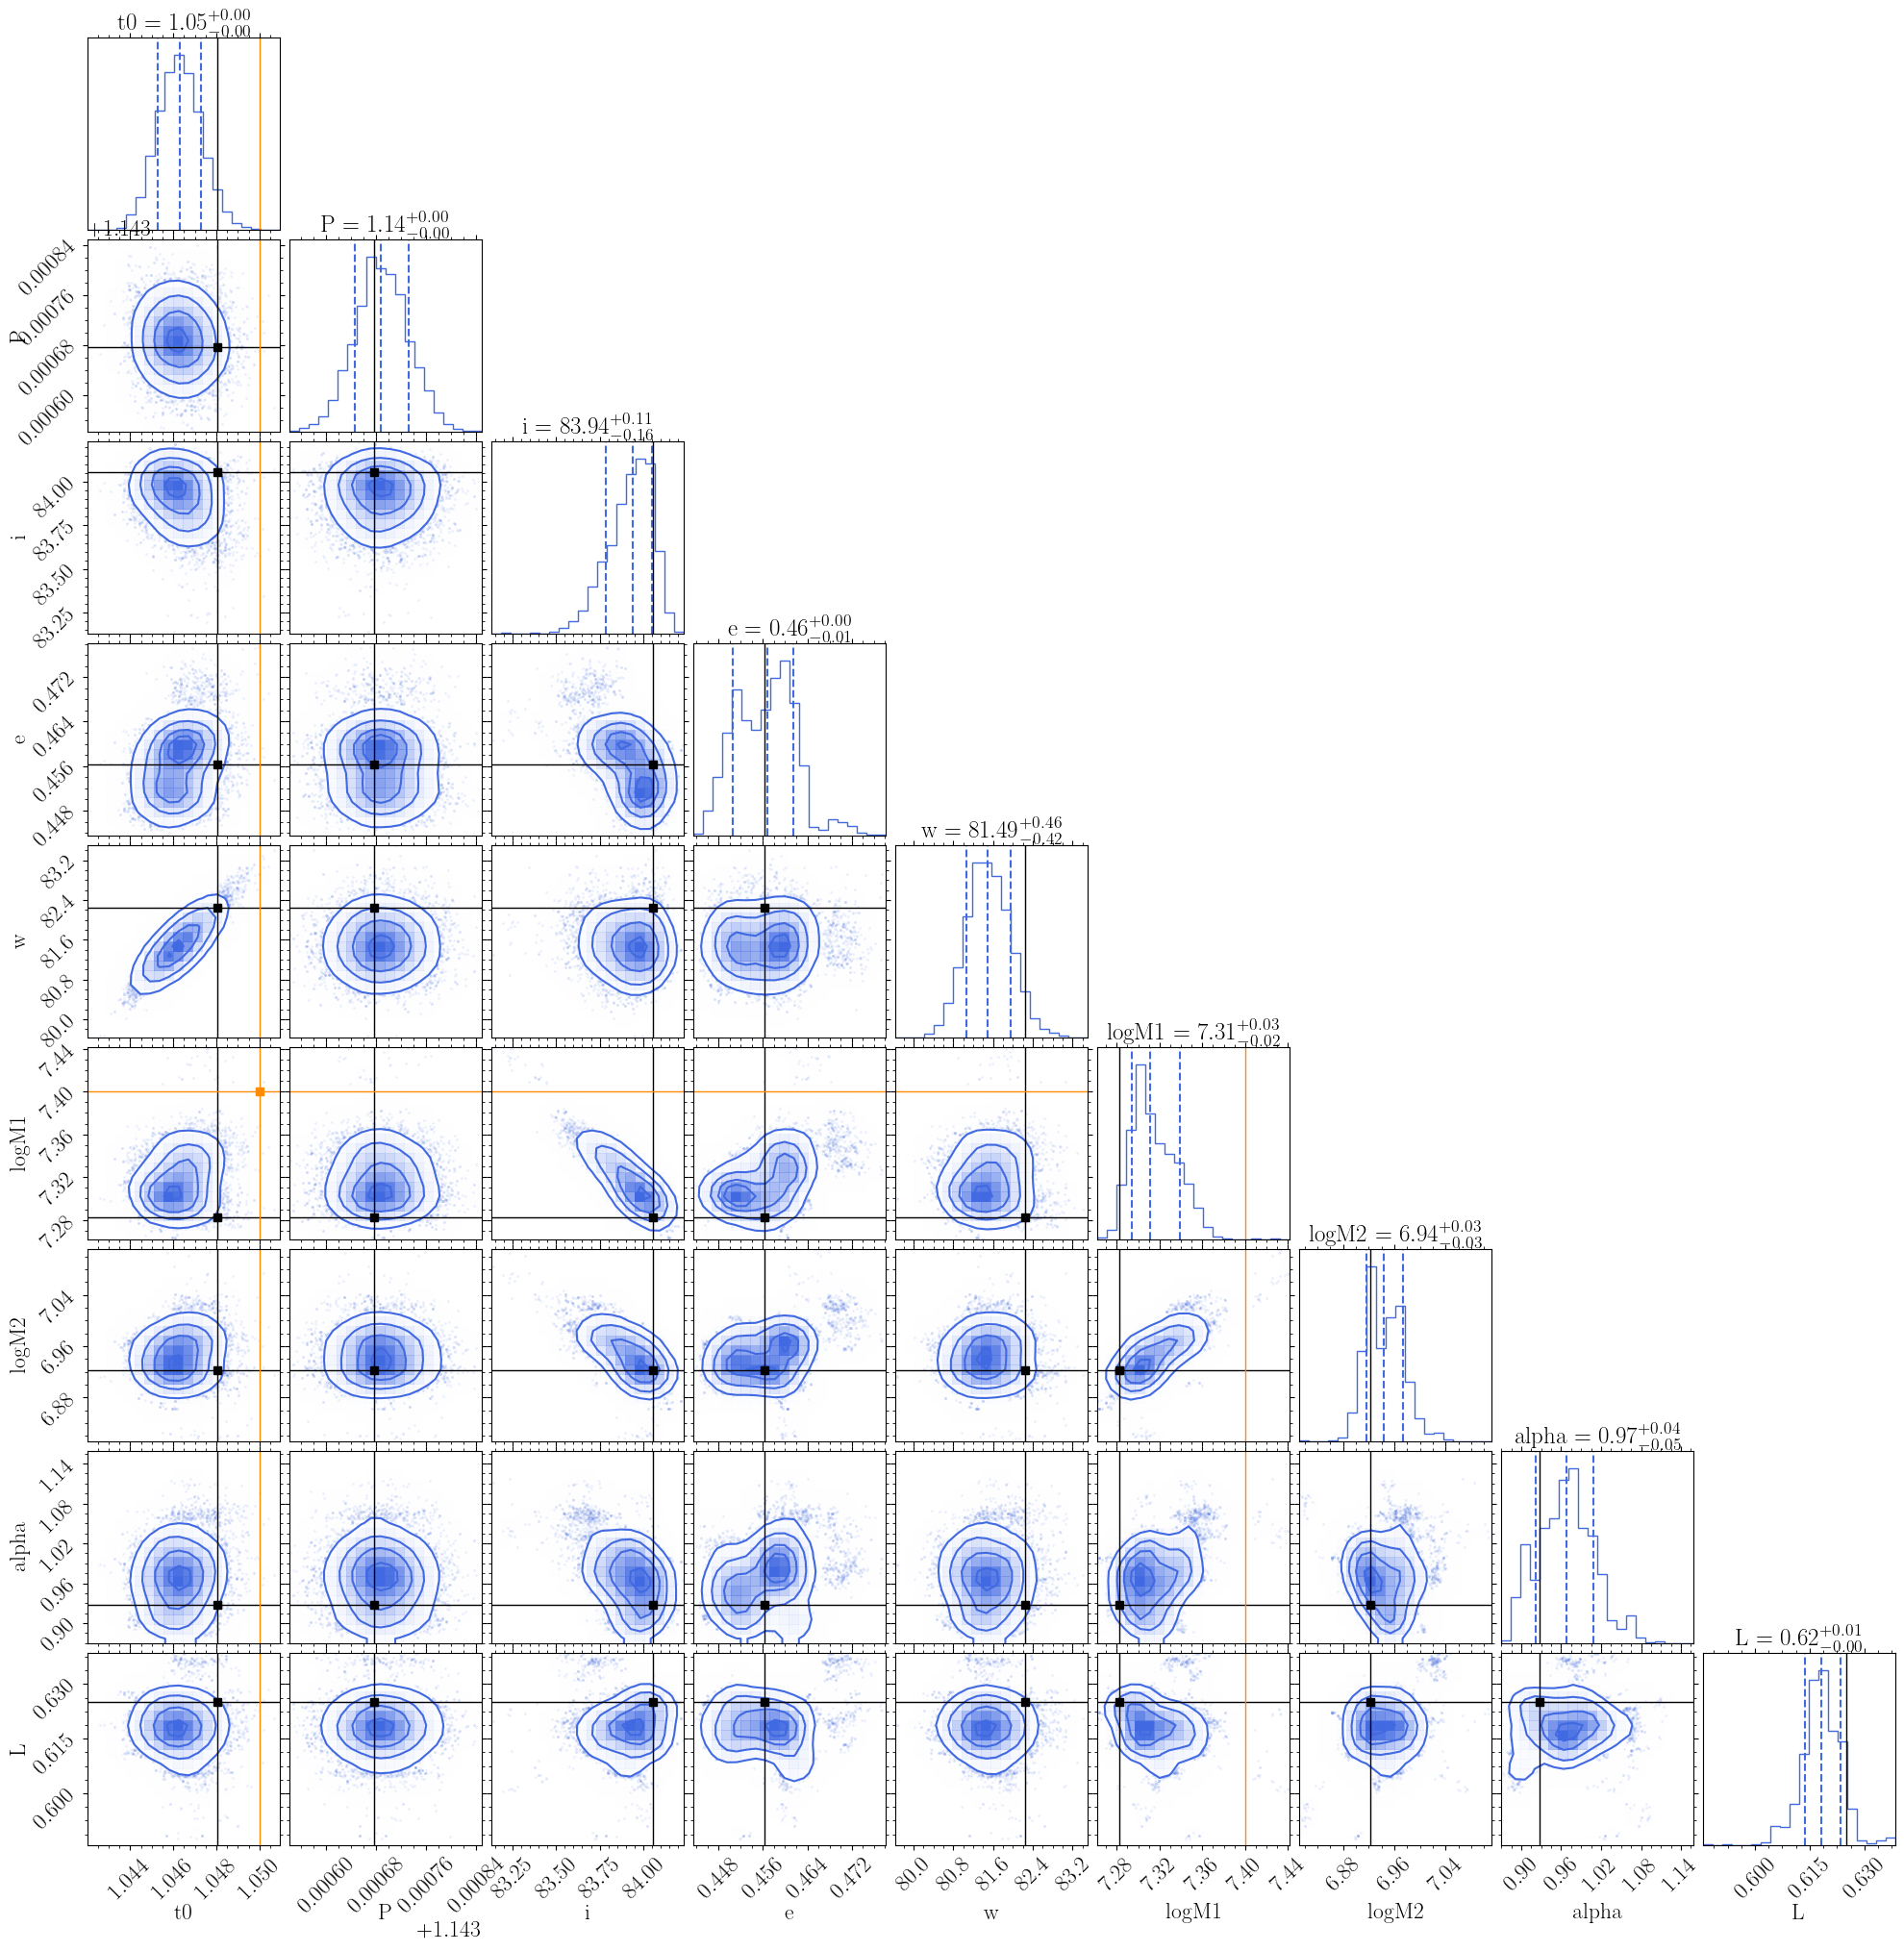

In [17]:
# Plot best-fit to Kepler light curve
dm_kepler = smbhb.model_lightcurve(df_kepler.time.to_numpy(), result['likelihood']['mle'])
fig, ax = pt.plot_result(df_kepler, dm_kepler, Q0=1)
# Plot best-fit to Plato light curve
dm_plato = smbhb.model_lightcurve(df_plato.time.to_numpy(), result['likelihood']['mle'])
fig, ax = pt.plot_result(df_plato, dm_plato, Q0=1)
# Plot coner for combined model
fig = pt.plot_corner(result, best_params='mle', true_params=True);

In [21]:
# # Resolve bimodality in w
# clusters_w = bs.get_posterior_clusters(df, result, param_cluster='w', n_components=2)
# result_w0 = clusters_w[0]
# result_w1 = clusters_w[1]
# fig = pt.plot_corner(result_w0, best_params='mle', true_params=True, color=c0)
# fig = pt.plot_corner(result_w1, best_params='mle', true_params=True, color=c1)

In [24]:
# Print percentiles for latex
ut.get_percentiles(result, latex=True);

t0 : pmx { 1.04628 }{ -0.00099 }{ 0.00100 }
P : pmx { 1.14369 }{ -0.00004 }{ 0.00004 }
i : pmx { 83.94073 }{ -0.15556 }{ 0.10702 }
e : pmx { 0.45675 }{ -0.00615 }{ 0.00468 }
w : pmx { 81.49104 }{ -0.42325 }{ 0.46043 }
logM1 : pmx { 7.31108 }{ -0.01659 }{ 0.02804 }
logM2 : pmx { 6.94368 }{ -0.02787 }{ 0.02977 }
alpha : pmx { 0.96756 }{ -0.04541 }{ 0.04133 }
L : pmx { 0.61820 }{ -0.00455 }{ 0.00539 }
